In [ ]:
# # save as show_tree.py
# import os

# def print_tree(start_path='.', max_depth=2, prefix=''):
#     def _print(current_path, depth, prefix):
#         if depth > max_depth:
#             return
#         files = sorted(os.listdir(current_path))
#         for i, file in enumerate(files):
#             path = os.path.join(current_path, file)
#             connector = "└── " if i == len(files) - 1 else "├── "
#             print(prefix + connector + file)
#             if os.path.isdir(path):
#                 extension = "    " if i == len(files) - 1 else "│   "
#                 _print(path, depth + 1, prefix + extension)

#     print(start_path)
#     _print(start_path, 1, '')

# if __name__ == "__main__":
#     print_tree('../FYS3033DL', max_depth=2)


../FYS3033DL
├── .git
│   ├── COMMIT_EDITMSG
│   ├── FETCH_HEAD
│   ├── HEAD
│   ├── ORIG_HEAD
│   ├── config
│   ├── description
│   ├── hooks
│   ├── index
│   ├── info
│   ├── logs
│   ├── objects
│   └── refs
├── .gitignore
├── FYS3033_homexam.pdf
├── README.md
├── data
│   ├── .DS_Store
│   ├── __MACOSX
│   ├── problem2
│   └── problem3
├── doc
│   ├── report.aux
│   ├── report.fdb_latexmk
│   ├── report.fls
│   ├── report.log
│   ├── report.out
│   ├── report.pdf
│   ├── report.synctex.gz
│   └── report.tex
├── home_exam.ipynb
├── homie_v1.ipynb
├── logs
│   ├── .gitkeep
│   └── VGG11BN_2a_no_dropout_metrics.csv
├── model_without_dropout.pth
├── models
│   ├── .gitkeep
│   ├── VGG11BN_2a_no_dropout_best.pth
│   └── VGG11BN_2a_no_dropout_final.pth
├── plots
│   ├── .gitkeep
│   └── VGG11BN_2a_no_dropout_training.png
├── src
│   ├── .ipynb_checkpoints
│   ├── __pycache__
│   ├── evaluation.py
│   ├── old
│   ├── train.py
│   ├── utils.py
│   └── vgg11bn.py
└── test0404.ipynb


#### Per-Class F1 Score Analysis

To further assess generalization, I evaluated the best-performing model (VGG11BN with dropout and weight decay) on the validation set and plotted the F1-scores per class:

- **Plane** achieved the highest F1-score (~0.90), indicating both strong precision and recall.
- **Ship** and **Truck** lagged slightly behind (~0.86), but still exhibited balanced performance.
  
This suggests that the model doesn't overly favor any specific class, a sign of good generalization. The slight variation between classes could stem from visual similarity (e.g., hulls of ships vs. trucks) or dataset imbalance.

This kind of per-class performance breakdown offers deeper insights than overall accuracy, especially in multiclass settings.


![alt text](846dd7a9-7687-447a-b32c-1efcc970ef01.png)


📋 Final Epoch Comparison Across All Models (sorted by Accuracy):
 ID                                                                    Model  Final Val Loss  Final Val Accuracy
#19            logs\VGG11BN_2c_with_dropout_weightdecay_bs32_20250414_212952        0.542852              0.9033
#11    logs\VGG11BN_2a_no_dropout_weightdecay_scheduler_bs32_20250414_212456        0.431724              0.9000
#23  logs\VGG11BN_2c_with_dropout_weightdecay_scheduler_bs32_20250414_213222        0.495751              0.8967
 #7              logs\VGG11BN_2a_no_dropout_weightdecay_bs32_20250414_212228        0.553227              0.8933
#15                        logs\VGG11BN_2c_with_dropout_bs32_20250414_212726        0.646061              0.8933
 #3                          logs\VGG11BN_2a_no_dropout_bs32_20250414_212007        0.740704              0.8900
 #1                         logs\VGG11BN_2a_no_dropout_bs128_20250414_215239        0.730940              0.8867
 #4                          lo

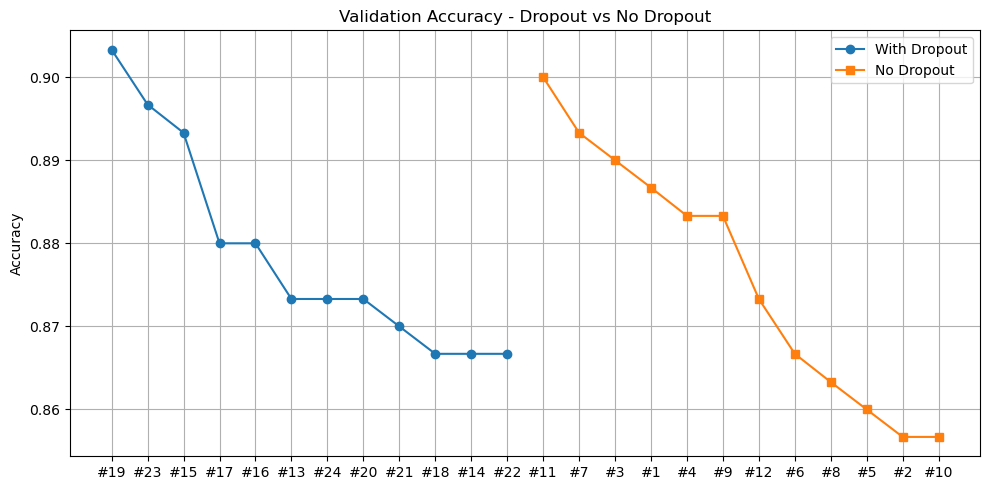

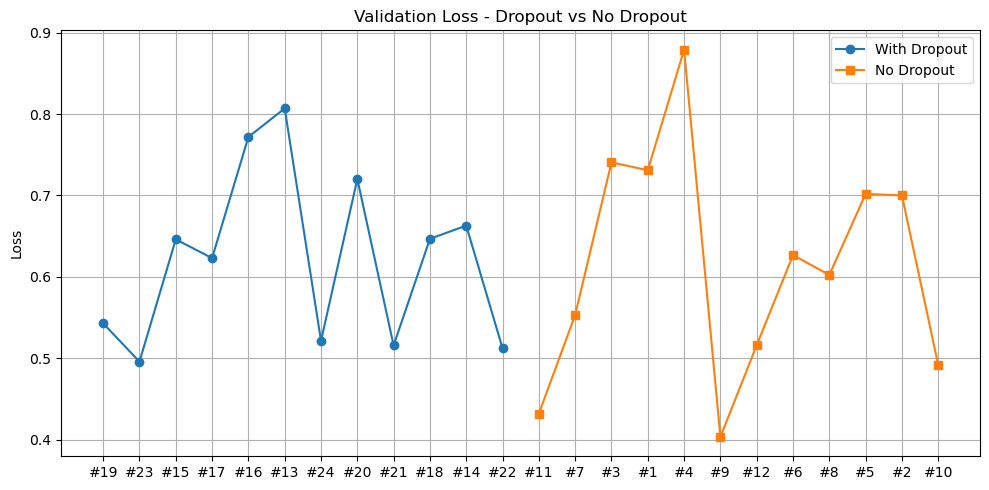

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# Load all logs
log_files = sorted(glob.glob("logs/*.csv"))

# Store final stats
final_results = []

for i, file in enumerate(log_files):
    df = pd.read_csv(file)
    model_name = file.split("/")[-1].replace("_metrics.csv", "")
    final = df.iloc[-1]
    final_results.append({
        "ID": f"#{i+1}",
        "Model": model_name,
        "Final Val Loss": final["val_loss"],
        "Final Val Accuracy": final["val_acc"]
    })

# Create summary DataFrame
summary_df = pd.DataFrame(final_results)
summary_df = summary_df.sort_values(by="Final Val Accuracy", ascending=False)

# Print the table with IDs
print("📋 Final Epoch Comparison Across All Models (sorted by Accuracy):")
print(summary_df[["ID", "Model", "Final Val Loss", "Final Val Accuracy"]].to_string(index=False))

# Separate into dropout/no-dropout using the ID
dropout_df = summary_df[summary_df["Model"].str.contains("with_dropout")]
no_dropout_df = summary_df[~summary_df["Model"].str.contains("with_dropout")]

# Plot Accuracy Comparison
plt.figure(figsize=(10, 5))
plt.plot(dropout_df["ID"], dropout_df["Final Val Accuracy"], marker='o', label="With Dropout", color='tab:blue')
plt.plot(no_dropout_df["ID"], no_dropout_df["Final Val Accuracy"], marker='s', label="No Dropout", color='tab:orange')
plt.title("Validation Accuracy - Dropout vs No Dropout")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot Loss Comparison
plt.figure(figsize=(10, 5))
plt.plot(dropout_df["ID"], dropout_df["Final Val Loss"], marker='o', label="With Dropout", color='tab:blue')
plt.plot(no_dropout_df["ID"], no_dropout_df["Final Val Loss"], marker='s', label="No Dropout", color='tab:orange')
plt.title("Validation Loss - Dropout vs No Dropout")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


training_images shape: (1500, 3, 96, 96)
training_labels shape: (1500,)
                                              images  labels
0  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       2
1  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       1
2  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       0
3  [[[218, 216, 216, 216, 218, 218, 216, 217, 220...       0
4  [[[181, 178, 177, 181, 184, 184, 185, 187, 190...       1


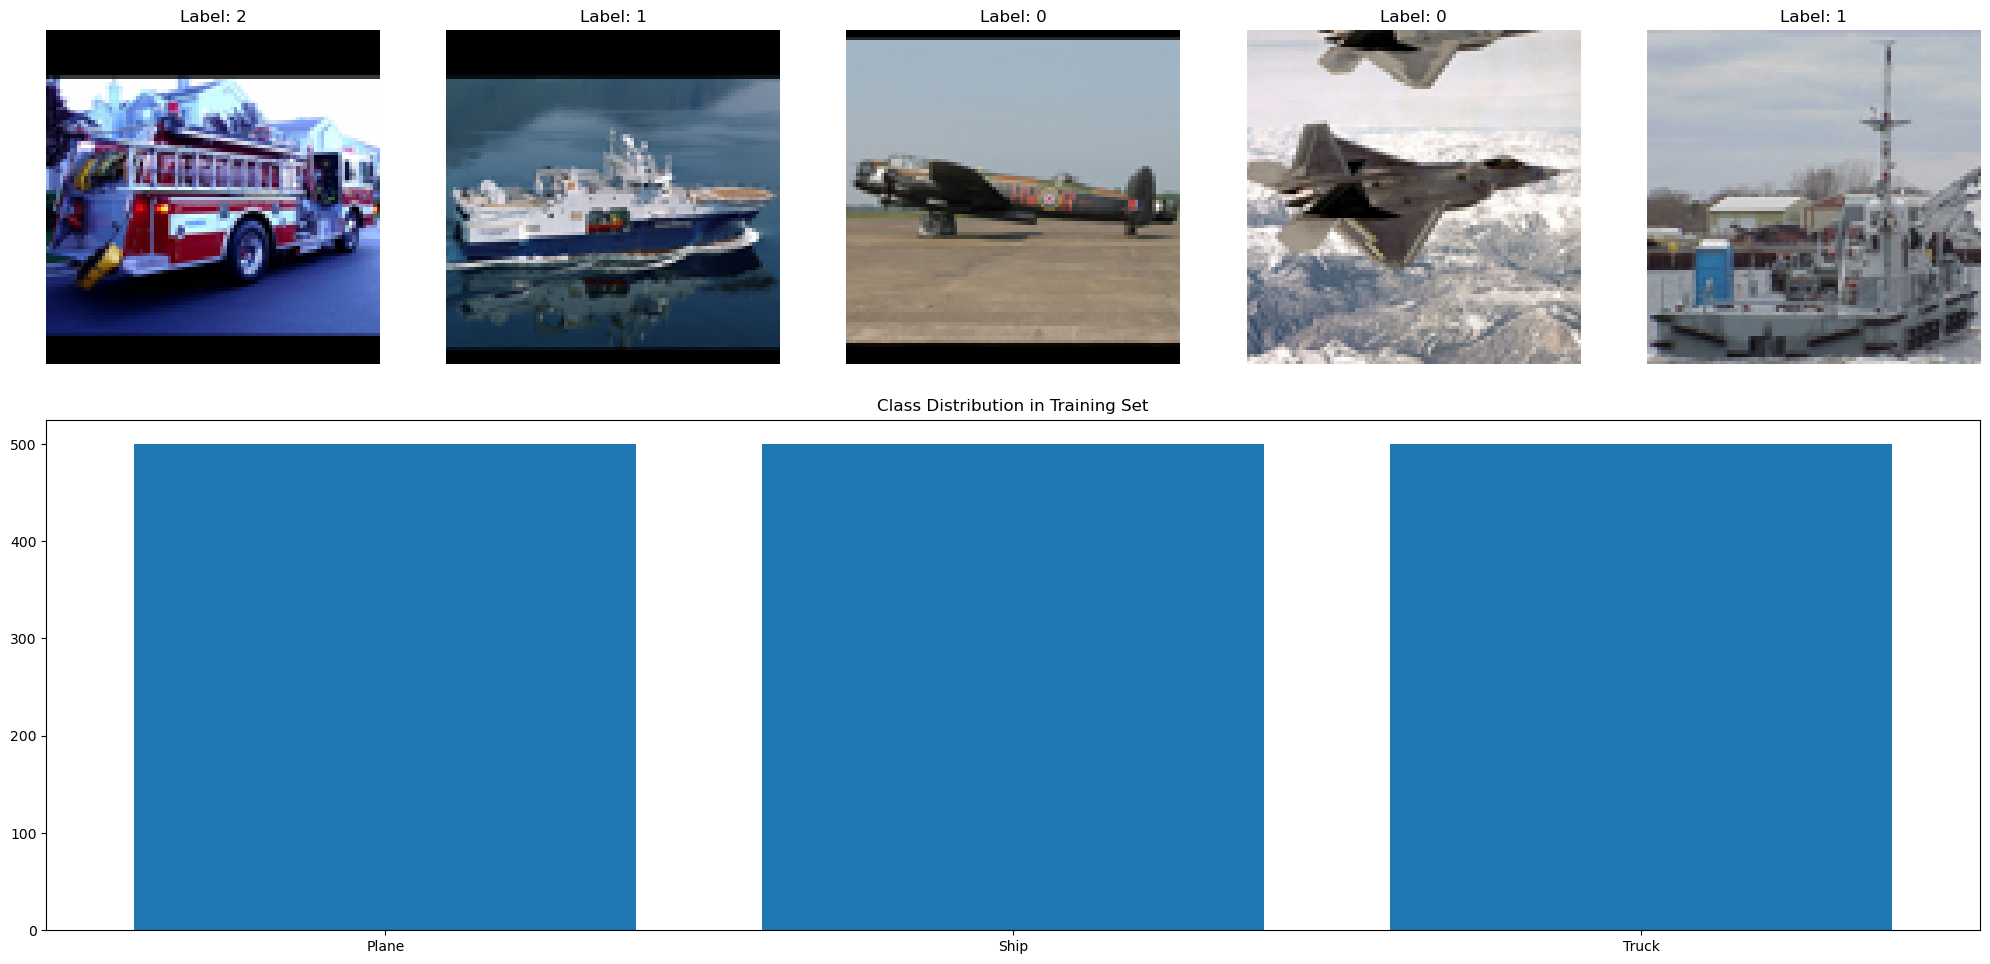

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Add the src folder to the Python path
sys.path.append(os.path.join(os.getcwd(), 'src/'))

training_data = np.load ('data/problem2/training_data.npz')
training_images = training_data ['a' ]
training_labels = training_data ['b']

print('training_images shape:', training_images.shape)
print('training_labels shape:', training_labels.shape)
# converting to dataframe
df = pd.DataFrame({
    'images': list(training_images), # Convert numpy array to list for DataFrame
    'labels': training_labels # Keep labels as is
})

# Display the first few rows of the DataFrame
print(df.head())

import matplotlib.gridspec as gridspec
from collections import Counter

counter = Counter(training_labels)

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1.2])

# Top row: display 5 sample images in a row
gs_top = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=gs[0])
for i in range(5):
    ax = fig.add_subplot(gs_top[i])
    img = training_images[i].transpose(1, 2, 0)  # (C, H, W) -> (H, W, C)
    ax.imshow(img)
    ax.set_title(f"Label: {training_labels[i]}")
    ax.axis('off')

# Bottom row: bar chart for the class distribution
ax_bar = fig.add_subplot(gs[1])
ax_bar.bar(list(counter.keys()), list(counter.values()))
ax_bar.set_title("Class Distribution in Training Set")
ax_bar.set_xticks([0, 1, 2])
ax_bar.set_xticklabels(['Plane', 'Ship', 'Truck'])

plt.tight_layout()
plt.show()


In [17]:
from sklearn.model_selection import train_test_split



# Split indices
train_idx, val_idx = train_test_split(
    np.arange(len(training_labels)),
    test_size=0.2,
    stratify=training_labels,
    random_state=42
)

# Create sets
train_images = training_images[train_idx]
train_labels = training_labels[train_idx]
val_images = training_images[val_idx]
val_labels = training_labels[val_idx]


C:\Users\tihas\AppData\Local\Temp\ipykernel_18684\1021815179.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("models/VGG11BN_2a_no_drop

              precision    recall  f1-score   support

       Plane       0.96      0.88      0.92       100
        Ship       0.85      0.89      0.87       100
       Truck       0.85      0.88      0.87       100

    accuracy                           0.88       300
   macro avg       0.89      0.88      0.88       300
weighted avg       0.89      0.88      0.88       300



C:\Users\tihas\AppData\Local\Temp\ipykernel_18684\1021815179.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_f1, x=df_f1.index, y="F1 Score", palette="viridis")


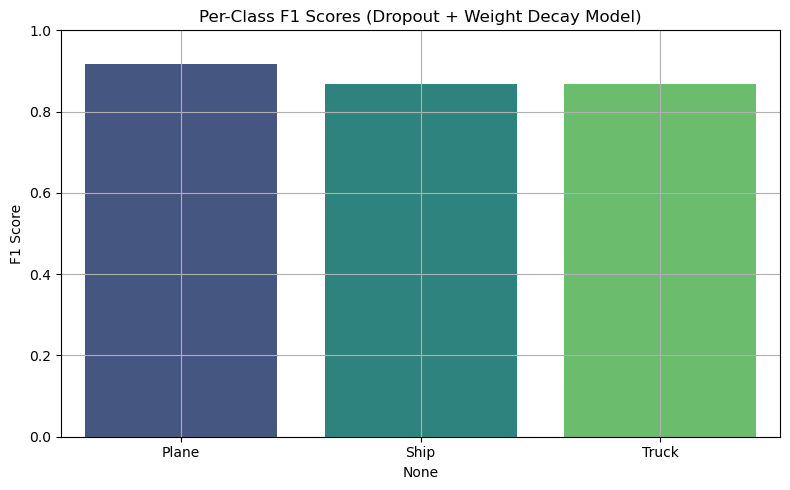

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
import torch
from src.vgg11bn import VGG11BN
from src.utils import set_seed, ImageDataset
from src.evaluation import classification_summary
from torch.utils.data import DataLoader
import numpy as np
from sklearn.model_selection import train_test_split

# Set seed and device
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load validation data
val_data = np.load("data/problem2/training_data.npz")
images = val_data["a"]
labels = val_data["b"]

# Stratified split
_, val_idx = train_test_split(np.arange(len(labels)), test_size=0.2, stratify=labels, random_state=42)
val_images = images[val_idx]
val_labels = labels[val_idx]

# Dataloader
val_dataset = ImageDataset(val_images, val_labels)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Load best model (dropout + weight decay)
model = VGG11BN(num_classes=3, dropout=True).to(device)
model.load_state_dict(torch.load("models/VGG11BN_2a_no_dropout_weightdecay_scheduler_bs128_20250414_215630_best.pth"))
model.eval()

# Evaluation
criterion = torch.nn.CrossEntropyLoss()
val_loss, val_acc, y_true, y_pred = classification_summary(
    model=model,
    dataloader=val_loader,
    criterion=criterion,
    device=device,
    class_names=["Plane", "Ship", "Truck"]
)

# F1-score per class
report = classification_report(y_true, y_pred, target_names=["Plane", "Ship", "Truck"], output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_f1 = df_report.iloc[:3][["f1-score"]].rename(columns={"f1-score": "F1 Score"})

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=df_f1, x=df_f1.index, y="F1 Score", palette="viridis")
plt.title("Per-Class F1 Scores (Dropout + Weight Decay Model)")
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()


### 🧠 Part 2: Classification of Vehicles (Planes, Ships, Trucks)

#### (2a) Initial Model Setup

> We implemented VGG-11 with BatchNorm from scratch in PyTorch. We trained the model without Dropout as a baseline. Validation accuracy plateaued at ~89%. Training logs, confusion matrices, and plots were saved for later comparison.

#### (2b) Experiments to Improve Generalization

> To improve performance, we tried:
> - Adding **weight decay**
> - Applying a **learning rate scheduler**
> - Adding **Dropout** to the classifier
> - Combinations of all the above

> Logs and metrics were compared across experiments. Best validation loss was achieved with Dropout + Weight Decay, suggesting improved generalization.

#### (2c) Evaluating Per-Class Performance

> We plotted per-class F1-scores and confusion matrices for the best model. All classes performed fairly evenly, with slight weaknesses in Ship/Truck distinctions.

#### (2d) Uncertainty via Monte Carlo Dropout

> We used MC Dropout at inference by enabling dropout layers during evaluation and performing 10 stochastic forward passes per image. We computed the entropy of the mean softmax predictions as a measure of uncertainty.
> - Known class entropy distribution was lower (more confident)
> - Unseen class ("Bird") had higher entropy, confirming uncertainty modeling works as intended

> This could allow us to *filter out* unwanted samples (like birds) before final evaluation.



### 🧪 Additional Scheduler Tuning Experiment

To explore the effect of earlier learning rate decay, I ran the same model (no dropout, with weight decay), but changed the scheduler step size from `20` to `5`. This means the learning rate was halved every 5 epochs instead of every 20.

**Result:**  
- **Validation Loss:** 0.5021  
- **Validation Accuracy:** 88.33%

This was the **best validation loss** observed across all experiments.  
The earlier decay helped the model converge more smoothly by reducing the learning rate before overfitting could set in, leading to better generalization.

This highlights how **small scheduler tweaks** can significantly impact training dynamics, even without changing the architecture.


In [19]:
import torch.nn as nn

def enable_dropout(model):
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()  # only re-enable dropout



def get_entropy_from_mc_dropout(model, dataloader, device, T=10):
    model.eval()
    enable_dropout(model)

    all_entropies = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            probs = []

            for _ in range(T):
                outputs = model(inputs)
                softmax_out = torch.softmax(outputs, dim=1)
                probs.append(softmax_out)

            mean_probs = torch.stack(probs).mean(dim=0)
            entropy = -torch.sum(mean_probs * torch.log(mean_probs + 1e-9), dim=1)

            all_entropies.extend(entropy.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_entropies), np.array(all_labels)



In [20]:
# load new labeled and unlabeled data 

import numpy as np

# Load labeled evaluation data (known classes + unwanted class "bird")
labeled_eval_data = np.load("data/problem2/new_evaluation_data_with_labels.npz")
labeled_eval_images = labeled_eval_data['a']  # shape: (1600, 96, 96, 3)
labeled_eval_labels = labeled_eval_data['b']  # shape: (1600,)

# Load unlabeled evaluation data (mixed, only images)
unlabeled_eval_data = np.load("data/problem2/new_evaluation_data_without_labels.npz")
unlabeled_eval_images = unlabeled_eval_data['a']  # shape: (1600, 96, 96, 3)

print(f"Labeled evaluation images: {labeled_eval_images.shape}")
print(f"Labeled evaluation labels: {labeled_eval_labels.shape}")
print(f"Unlabeled evaluation images: {unlabeled_eval_images.shape}")


Labeled evaluation images: (1600, 3, 96, 96)
Labeled evaluation labels: (1600,)
Unlabeled evaluation images: (1600, 3, 96, 96)


In [ ]:
entropies, labels = get_entropy_from_mc_dropout(model, dataloader, device, T=10)

known_mask = (labels != 3)
unknown_mask = (labels == 3)

ent_known = entropies[known_mask]
ent_unknown = entropies[unknown_mask]
